# 01 — Load and Visualize Geometry

This notebook loads one STEP model, prints geometry metadata, and renders a Python preview.
It uses the sample STEP file from the run directory when available.

## What this notebook does

- Creates the baseline run directory.
- Loads the sample STEP source from the run directory.
- Prints explicit file paths and summary metadata.
- Renders the geometry preview in Python.

In [1]:
import json
import logging
import sys
from dataclasses import asdict, is_dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')


In [2]:

def find_module_root(start: Path | None = None) -> Path:
    current = start or Path.cwd()
    for candidate in [current, *current.parents]:
        if (candidate / 'src').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate the fea_cad_one_sample module root.')

def json_safe(value: Any) -> Any:
    if is_dataclass(value):
        return json_safe(asdict(value))
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(item) for item in value]
    return value

def write_json(path: Path, payload: Any) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(json_safe(payload), indent=2, sort_keys=True) + '\n', encoding='utf-8')
    return path

def load_json(path: Path) -> dict[str, Any]:
    return json.loads(Path(path).read_text(encoding='utf-8'))

MODULE_ROOT = find_module_root()
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

import src.interfaces as iface

plt.style.use('seaborn-v0_8-whitegrid')
print(f'[SETUP] MODULE_ROOT={MODULE_ROOT}')

[SETUP] MODULE_ROOT=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample


In [3]:
RUN_DIR = MODULE_ROOT / 'outputs' / 'sample_00689964' / '01_dataset_original'
SOURCE_STEP_PATH = RUN_DIR / "original.step"  # Load the sample STEP model from the run directory.
MESH_SIZE_MM = 8.0
LOAD_MAGNITUDE_N = 100.0

print('[STAGE] geometry: build config and prepare STEP source')
print(f'  RUN_DIR={RUN_DIR}')
print(f'  SOURCE_STEP_PATH={SOURCE_STEP_PATH}')
print(f'  SOURCE_STEP_EXISTS={SOURCE_STEP_PATH.exists()}')
config = iface.build_baseline_config(
    run_dir=RUN_DIR,
    source_step_path=SOURCE_STEP_PATH,
    mesh_size_mm=MESH_SIZE_MM,
    load_magnitude_n=LOAD_MAGNITUDE_N,
)
print('  config:', json.dumps(json_safe(config), indent=2))

INFO src.fea_replication.pipeline: build_baseline_config | start | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original | source_step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/original.step | mesh_size_mm=8.0 | load_magnitude_n=100.0
INFO src.fea_replication.pipeline: build_baseline_config | done | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original


[STAGE] geometry: build config and prepare STEP source
  RUN_DIR=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original
  SOURCE_STEP_PATH=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/original.step
  SOURCE_STEP_EXISTS=True
  config: {
  "run_dir": "/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original",
  "job_name": "analysis",
  "mesh_size_mm": 8.0,
  "geometry": {
    "source_step_path": "/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/original.step",
    "placeholder_name": "cantilever_beam",
    "length_mm": 120.0,
    "width_mm": 20.

INFO src.fea_replication.geometry: prepare_geometry_artifacts | start | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original | source_step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/original.step | force=True
INFO src.fea_replication.geometry: render_geometry_preview | start | step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/cantilever_beam.step | output_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/geometry_preview.png | force=True
INFO src.fea_replication.geometry: render_geometry_preview | done | ou

  geometry.step_path = /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/cantilever_beam.step
  geometry.preview_path = /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/geometry_preview.png
  geometry.summary_path = /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/geometry_summary.json
  geometry.stl_path = /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/cantilever_beam.stl
  geometry metadata:
{
  "source_mode": "provided_step",
  "step_path": "/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics

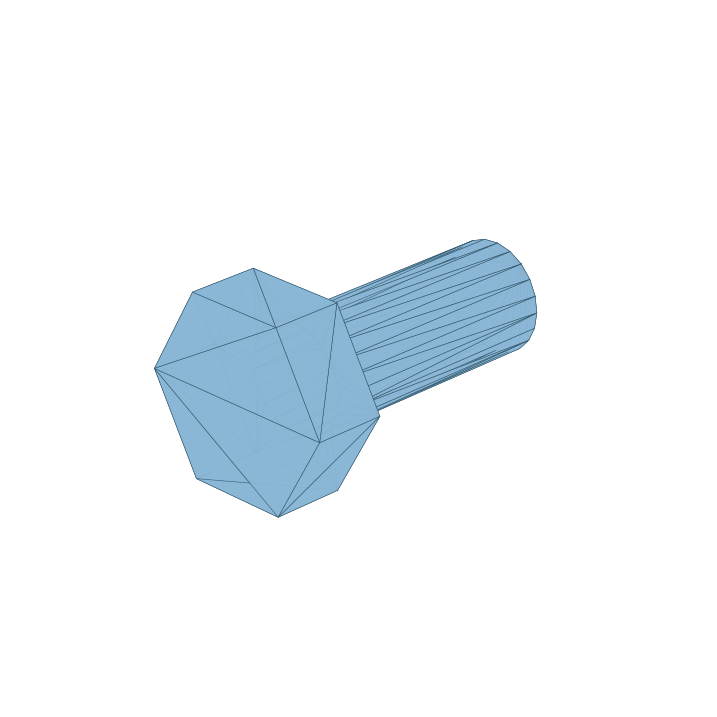

✓ geometry ready


In [4]:

geometry = iface.prepare_geometry_artifacts(config, force=True)
print('  geometry.step_path =', geometry.step_path)
print('  geometry.preview_path =', geometry.preview_path)
print('  geometry.summary_path =', geometry.summary_path)
print('  geometry.stl_path =', geometry.stl_path)
print('  geometry metadata:')
print(json.dumps(json_safe(geometry), indent=2))
display(Image(filename=str(geometry.preview_path)))
print('✓ geometry ready')